# Notebook 5 - Replicacion del pipeline Thesis con data-iipsi

**Objetivo:** reproducir exactamente el pipeline de `Thesis/Code` (Prado et al., en prep.) con los datos de data-iipsi para comparar sus resultados con los de las metricas topologicas (Notebook 3).

## Pipeline replicado
1. beta-VAE (FC 6670 features -> embeddings Z 64 dims) — hiperparametros de Optuna Thesis
2. XGBoost / Ridge / SVR para prediccion de edad cerebral
3. 7 configuraciones de features (ablaciones del Thesis main.ipynb)
4. Comparacion Ridge vs SVR vs XGBoost (Thesis model_comparison.ipynb)
5. BAG con la mejor configuracion

## Hiperparametros (copiados literalmente del Thesis)
| Componente | Parametro | Valor |
|-----------|-----------|-------|
| beta-VAE | hidden_dims | [512] |
| beta-VAE | latent_dim | 64 |
| beta-VAE | activation | elu |
| beta-VAE | norm_kind | layer |
| beta-VAE | beta_target | 0.0567 |
| beta-VAE | warmup_ep | 73 |
| beta-VAE | drop_rate | 0.0369 |
| beta-VAE | lr | 0.001892 |
| beta-VAE | recon_kind | mae |
| beta-VAE | max_epochs | 150 |
| XGBoost | n_estimators | 2103 |
| XGBoost | max_depth | 6 |
| XGBoost | learning_rate | 0.0110 |
| XGBoost | subsample | 0.5021 |
| XGBoost | colsample_bytree | 0.9506 |
| Ridge | alpha | 267.7 |
| SVR | C / epsilon | 10.0 / 0.5 |

**Split:** 90% trainval / 10% test, estratificado por sexo x diagnostico.  
**CV:** 5-fold sobre trainval.  
**Entrenamiento BAG:** solo CN.  
**VAE:** entrenado sobre TODOS los sujetos trainval (no solo CN) — igual que Thesis.

In [1]:
import sys, os
sys.path.insert(0, "Thesis/Code")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
import warnings
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import KFold, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

from src.vae_train import train_vae_final, load_vae_from_dir
from src.splits import make_holdout_split
from src.metrics import regression_metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
os.makedirs("figs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/models_thesis", exist_ok=True)

SEED = 42
np.random.seed(SEED)

# Hiperparametros Thesis (copiados literalmente)
VAE_HP = dict(
    hidden_dims=[512], latent_dim=64, activation="elu",
    norm_kind="layer", beta_target=0.0567, warmup_ep=73,
    l2_reg=1e-4, drop_rate=0.0369, recon_kind="mae",
    lr=0.001892, clipnorm=1.0, max_epochs=150, batch_size=64,
)
XGB_HP = dict(
    n_estimators=2103, max_depth=6, learning_rate=0.0110,
    subsample=0.5021, colsample_bytree=0.9506,
    reg_alpha=0.00136, reg_lambda=7.084, min_child_weight=1.142,
    gamma=0.675, tree_method="hist", eval_metric="mae",
    random_state=SEED, verbosity=0,
)

make_xgb = lambda: Pipeline([("sc", StandardScaler()), ("m", XGBRegressor(**XGB_HP))])
make_rdg = lambda: Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=267.7))])
make_svr = lambda: Pipeline([("sc", StandardScaler()), ("m", SVR(kernel="rbf", C=10.0, epsilon=0.5))])

COLORS = {"CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26"}
print("Setup completo. Hiperparametros Thesis cargados.")

Setup completo. Hiperparametros Thesis cargados.


## 1. Cargar datos

In [2]:
# Cohorte elegible
eligible = pd.read_csv("outputs/eligible_fc_subjects.csv")

# T1w: 116 features AAL (igual que Thesis: Redlat_VGM_AAL_.csv)
vbm_raw  = pd.read_csv("outputs/vbm_features.csv")
t1w_cols = [c for c in vbm_raw.columns
            if c.startswith("gm_") and c not in ["gm_total", "gm_fp_mean"]]

# Tabla de trabajo: sujetos con edad conocida
df = eligible.dropna(subset=["Age"]).merge(
    vbm_raw[["MRI_ID"] + t1w_cols], on="MRI_ID", how="left"
).reset_index(drop=True)

print(f"Sujetos elegibles: {len(df)}")
print(f"Con T1w: {df[t1w_cols[0]].notna().sum()}")
print(f"Diagnosticos: {df['diagnosis'].value_counts().to_dict()}")
print(f"Sitios: {df['site'].value_counts().to_dict()}")

Sujetos elegibles: 1327
Con T1w: 1245
Diagnosticos: {'CN': 555, 'AD': 468, 'FTD': 304}
Sitios: {'Miller': 400, 'Matallana': 135, 'Bruno': 125, 'Takada': 93, 'Slachevsky': 93, 'Lopera': 89, 'Behrens': 60, 'Resende': 19, 'Avila': 9}


In [3]:
# Vectores FC: triangulo superior de la matriz 116x116 = 6670 features
FC_DIR = Path("outputs/fc_matrices")
triu_i, triu_j = np.triu_indices(116, k=1)

fc_vectors = {}
for _, row in df.iterrows():
    p = FC_DIR / f"{row['MRI_ID']}_fc_z.npy"
    if p.exists():
        fc_vectors[row["MRI_ID"]] = np.load(p)[triu_i, triu_j].astype(np.float32)

# Sujetos con FC + T1w (requerido para el pipeline Thesis)
df_full = df[
    df["MRI_ID"].isin(fc_vectors) &
    df[t1w_cols[0]].notna()
].copy().reset_index(drop=True)

print(f"Sujetos con FC + T1w: {len(df_full)}")
print(f"Vectores FC: {len(fc_vectors)} (6670 features c/u)")
print(f"T1w features: {len(t1w_cols)} regiones AAL")

Sujetos con FC + T1w: 1245
Vectores FC: 1327 (6670 features c/u)
T1w features: 116 regiones AAL


## 2. Split de datos

90% trainval / 10% test, estratificado por sexo x diagnostico — identico a Thesis `src/splits.py`.

In [5]:
split    = make_holdout_split(
    df_full.rename(columns={"MRI_ID": "record_id"}),  # Thesis usa record_id
    seed=SEED, test_size=0.10,
)
tv_ids   = set(split["trainval_ids"])
test_ids = set(split["test_ids"])

df_tv   = df_full[df_full["MRI_ID"].isin(tv_ids)].copy().reset_index(drop=True)
df_test = df_full[df_full["MRI_ID"].isin(test_ids)].copy().reset_index(drop=True)
df_cn_tv   = df_tv[df_tv["diagnosis"] == "CN"].copy().reset_index(drop=True)
df_cn_test = df_test[df_test["diagnosis"] == "CN"].copy().reset_index(drop=True)

print(f"Trainval total: {len(df_tv)} | CN trainval: {len(df_cn_tv)}")
print(f"Test total:     {len(df_test)} | CN test:     {len(df_cn_test)}")
print(f"  Ref Thesis:  trainval=1120  CN=526  test=125")

Trainval total: 1120 | CN trainval: 473
Test total:     125 | CN test:     53
  Ref Thesis:  trainval=1120  CN=526  test=125


## 3. Matrices de features

Se construyen los arrays para todos los trainval (no solo CN) y para CN trainval.

In [6]:
# Arrays trainval completo (para entrenar el VAE)
tv_ids_list = df_tv["MRI_ID"].tolist()
X_fc_tv  = np.array([fc_vectors[s] for s in tv_ids_list], dtype=np.float32)
X_t1w_tv = df_tv[t1w_cols].fillna(0).values.astype(np.float32)
X_sex_tv = df_tv["sex"].values.reshape(-1, 1).astype(np.float32)

# Arrays CN trainval (para entrenar los regresores de edad)
cn_ids_list = df_cn_tv["MRI_ID"].tolist()
X_fc_cn  = np.array([fc_vectors[s] for s in cn_ids_list], dtype=np.float32)
X_t1w_cn = df_cn_tv[t1w_cols].fillna(0).values.astype(np.float32)
X_sex_cn = df_cn_tv["sex"].values.reshape(-1, 1).astype(np.float32)
y_cn     = df_cn_tv["Age"].values.astype(np.float32)

# Arrays CN test
X_fc_te  = np.array([fc_vectors[s] for s in df_cn_test["MRI_ID"]], dtype=np.float32)
X_t1w_te = df_cn_test[t1w_cols].fillna(0).values.astype(np.float32)
X_sex_te = df_cn_test["sex"].values.reshape(-1, 1).astype(np.float32)
y_te     = df_cn_test["Age"].values.astype(np.float32)

print(f"X_fc_tv:  {X_fc_tv.shape}")
print(f"X_fc_cn:  {X_fc_cn.shape}  y_cn: {y_cn.shape}")
print(f"X_t1w_cn: {X_t1w_cn.shape}")

X_fc_tv:  (1120, 6670)
X_fc_cn:  (473, 6670)  y_cn: (473,)
X_t1w_cn: (473, 116)


## 4. Entrenar beta-VAE

El VAE se entrena sobre TODOS los sujetos trainval (no solo CN) — igual que Thesis.  
Es un modelo no supervisado: comprime FC(6670) -> Z(64).

In [8]:
VAE_DIR = Path("outputs/models_thesis")

if (VAE_DIR / "vae.weights.h5").exists():
    print("Cargando VAE desde disco...")
    vae = load_vae_from_dir(VAE_DIR)
else:
    print(f"Entrenando beta-VAE sobre {len(X_fc_tv)} sujetos ({X_fc_tv.shape[1]} features)...")
    vae, hist = train_vae_final(
        X_fc_tv, out_dir=VAE_DIR,
        **{k: v for k, v in VAE_HP.items() if k not in ("seed", "max_epochs")},
        epochs=VAE_HP["max_epochs"], seed=SEED,
    )
    print("VAE guardado.")

# Extraer embeddings mu (deterministicos) para cada subconjunto
mu_tv, _, _ = vae.encoder.predict(X_fc_tv, verbose=0)
mu_cn, _, _ = vae.encoder.predict(X_fc_cn, verbose=0)
mu_te, _, _ = vae.encoder.predict(X_fc_te, verbose=0)

print(f"Embeddings mu: {mu_cn.shape}  (CN trainval)")

Entrenando beta-VAE sobre 1120 sujetos (6670 features)...

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - kl_loss: 12396.8955 - loss: 2027.3208 - recon_loss: 2027.3208 - learning_rate: 0.0019
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - kl_loss: 152501.8281 - loss: 1518.9507 - recon_loss: 1400.5007 - learning_rate: 0.0019
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - kl_loss: 705.4870 - loss: 1257.0122 - recon_loss: 1255.9164 - learning_rate: 0.0019
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - kl_loss: 681.8477 - loss: 1210.1763 - recon_loss: 1208.5874 - learning_rate: 0.0019
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - kl_loss: 690.8542 - loss: 1157.4098 - recon_loss: 1155.2634 - learning_rate: 0.0019
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - kl_loss: 669.4022 - loss: 1126.6072 - recon_loss: 1124.0076 - learning_rate: 0.0019
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - kl_loss: 649.7419 - loss: 1102.6163 - recon_lo

## 5. Ablaciones de features (replicando Thesis main.ipynb)

Las 7 configuraciones exactas del Thesis, en el mismo orden:

| Config | Features | Dims |
|--------|----------|------|
| T1w only | T1w(116) | 116 |
| T1w + sex | T1w(116) + sex | 117 |
| Z only | mu(64) | 64 |
| Z + sex | mu(64) + sex | 65 |
| Z + T1w | mu(64) + T1w(116) | 180 |
| **Z + T1w + sex** | mu(64) + T1w(116) + sex | **181** | <- Thesis final |
| Z + T1w + sex + diag | mu(64) + T1w(116) + sex + diag | 182 |

In [9]:
# Codificar diagnostico como entero para usarlo como feature
le = LabelEncoder()
le.fit(df_cn_tv["diagnosis"])
diag_cn = le.transform(df_cn_tv["diagnosis"]).reshape(-1, 1).astype(np.float32)

# Las 7 configuraciones
CONFIGS = {
    "T1w only":          X_t1w_cn,
    "T1w + sex":         np.hstack([X_t1w_cn, X_sex_cn]),
    "Z only":            mu_cn,
    "Z + sex":           np.hstack([mu_cn, X_sex_cn]),
    "Z + T1w":           np.hstack([mu_cn, X_t1w_cn]),
    "Z + T1w + sex":     np.hstack([mu_cn, X_t1w_cn, X_sex_cn]),
    "Z + T1w + sex + diag": np.hstack([mu_cn, X_t1w_cn, X_sex_cn, diag_cn]),
}

for name, X in CONFIGS.items():
    print(f"  {name:30s} -> {X.shape[1]} features")

  T1w only                       -> 116 features
  T1w + sex                      -> 117 features
  Z only                         -> 64 features
  Z + sex                        -> 65 features
  Z + T1w                        -> 180 features
  Z + T1w + sex                  -> 181 features
  Z + T1w + sex + diag           -> 182 features


## 6. Evaluacion 5-fold CV — tabla de ablaciones

In [10]:
def cv5(X, y, model_fn, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    ms = []
    for tr, va in kf.split(X):
        m = model_fn(); m.fit(X[tr], y[tr])
        ms.append(regression_metrics(y[va], m.predict(X[va])))
    return {k: {"mean": float(np.mean([f[k] for f in ms])),
               "std":  float(np.std([f[k] for f in ms]))}
            for k in ms[0]}

# Ablaciones con XGBoost (igual que Thesis)
ablation_rows = []
for cfg_name, X in CONFIGS.items():
    cv = cv5(X, y_cn, make_xgb)
    ablation_rows.append({
        "Configuracion": cfg_name,
        "Dims": X.shape[1],
        "MAE":  f"{cv['MAE']['mean']:.2f} +/- {cv['MAE']['std']:.2f}",
        "R2":   f"{cv['R2']['mean']:.3f}",
        "r":    f"{cv['Pearson']['mean']:.3f}",
        "_mae": cv["MAE"]["mean"],
    })
    print(f"{cfg_name:35s}  MAE={cv['MAE']['mean']:.2f}  R2={cv['R2']['mean']:.3f}")

ablation_df = pd.DataFrame(ablation_rows)
print("\n=== TABLA ABLACIONES (XGBoost, 5-fold CV, CN) ===")
print(ablation_df.drop("_mae", axis=1).to_string(index=False))
ablation_df.drop("_mae", axis=1).to_csv("outputs/thesis_ablation_table.csv", index=False)

T1w only                             MAE=7.14  R2=0.337
T1w + sex                            MAE=7.10  R2=0.346
Z only                               MAE=8.02  R2=0.139
Z + sex                              MAE=8.02  R2=0.144
Z + T1w                              MAE=7.03  R2=0.373
Z + T1w + sex                        MAE=7.00  R2=0.378
Z + T1w + sex + diag                 MAE=7.01  R2=0.374

=== TABLA ABLACIONES (XGBoost, 5-fold CV, CN) ===
       Configuracion  Dims           MAE    R2     r
            T1w only   116 7.14 +/- 0.59 0.337 0.584
           T1w + sex   117 7.10 +/- 0.59 0.346 0.591
              Z only    64 8.02 +/- 0.87 0.139 0.403
             Z + sex    65 8.02 +/- 0.86 0.144 0.410
             Z + T1w   180 7.03 +/- 0.66 0.373 0.619
       Z + T1w + sex   181 7.00 +/- 0.69 0.378 0.624
Z + T1w + sex + diag   182 7.01 +/- 0.71 0.374 0.621


In [11]:
# Comparacion con Thesis (valores reportados en main.ipynb)
thesis_ref = {
    "T1w only":          (5.89, 0.366),
    "T1w + sex":         (5.88, 0.372),
    "Z only":            (7.01, 0.056),
    "Z + sex":           (7.06, 0.044),
    "Z + T1w":           (5.62, 0.411),
    "Z + T1w + sex":     (5.70, 0.389),
    "Z + T1w + sex + diag": (5.64, 0.416),
}
print("\nComparacion con resultados del Thesis:")
print(f"  {"Config":30s}  {"MAE nuestro":>12}  {"MAE Thesis":>10}  {"R2 Thesis":>9}")
for row in ablation_rows:
    ref = thesis_ref.get(row["Configuracion"], (None, None))
    mae_ref = f"{ref[0]:.2f}" if ref[0] else "-"
    r2_ref  = f"{ref[1]:.3f}" if ref[1] else "-"
    print(f"  {row['Configuracion']:30s}  {row['MAE']:>12}  {mae_ref:>10}  {r2_ref:>9}")


Comparacion con resultados del Thesis:
  Config                           MAE nuestro  MAE Thesis  R2 Thesis
  T1w only                        7.14 +/- 0.59        5.89      0.366
  T1w + sex                       7.10 +/- 0.59        5.88      0.372
  Z only                          8.02 +/- 0.87        7.01      0.056
  Z + sex                         8.02 +/- 0.86        7.06      0.044
  Z + T1w                         7.03 +/- 0.66        5.62      0.411
  Z + T1w + sex                   7.00 +/- 0.69        5.70      0.389
  Z + T1w + sex + diag            7.01 +/- 0.71        5.64      0.416


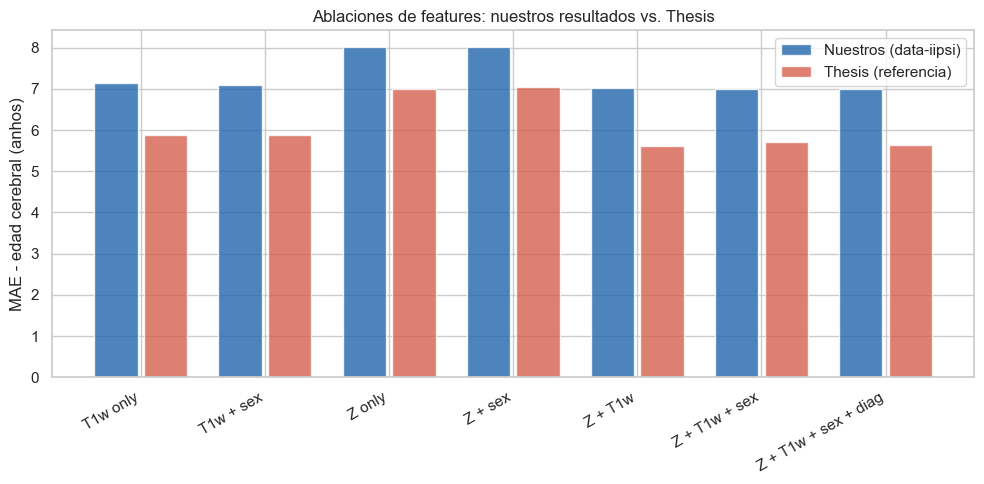

In [12]:
# Grafico de ablaciones
fig, ax = plt.subplots(figsize=(10, 5))
names  = [r["Configuracion"] for r in ablation_rows]
maes   = [r["_mae"] for r in ablation_rows]
refs   = [thesis_ref.get(n, (None,))[0] for n in names]

x = np.arange(len(names))
bars = ax.bar(x - 0.2, maes, 0.35, label="Nuestros (data-iipsi)", color="#2166ac", alpha=0.8)
bars2 = ax.bar(x + 0.2, [r if r else 0 for r in refs], 0.35,
               label="Thesis (referencia)", color="#d6604d", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("MAE - edad cerebral (anhos)")
ax.set_title("Ablaciones de features: nuestros resultados vs. Thesis")
ax.legend()
plt.tight_layout()
plt.savefig("figs/05_ablation_comparison.png", dpi=150)
plt.show()

## 7. Comparacion de modelos con configuracion Z + T1w

Replica de `Thesis/Code/notebooks/model_comparison.ipynb`:  
Ridge vs SVR vs XGBoost con la misma configuracion de features (Z + T1w).

In [13]:
# Configuracion Z + T1w (mejor segun Thesis en terms de MAE)
X_best = CONFIGS["Z + T1w"]

model_rows = []
for name, fn, ref_mae, ref_r2 in [
    ("Ridge (Thesis)", make_rdg, 5.75, 0.403),
    ("SVR   (Thesis)", make_svr, 5.65, 0.441),
    ("XGBoost (Thesis)", make_xgb, 5.62, 0.411),
]:
    cv = cv5(X_best, y_cn, fn)
    model_rows.append({
        "Modelo": name,
        "MAE CV": f"{cv['MAE']['mean']:.2f} +/- {cv['MAE']['std']:.2f}",
        "R2 CV":  f"{cv['R2']['mean']:.3f}",
        "r CV":   f"{cv['Pearson']['mean']:.3f}",
        "MAE Thesis": ref_mae,
        "R2 Thesis":  ref_r2,
        "_mae": cv["MAE"]["mean"],
    })
    print(f"{name:20s}  MAE={cv['MAE']['mean']:.2f}  R2={cv['R2']['mean']:.3f}  "
          f"(Thesis: MAE={ref_mae:.2f} R2={ref_r2:.3f})")

model_df = pd.DataFrame(model_rows)
print("\n=== TABLA MODELOS (Z + T1w, 5-fold CV, CN) ===")
print(model_df.drop("_mae", axis=1).to_string(index=False))
model_df.drop("_mae", axis=1).to_csv("outputs/thesis_model_comparison.csv", index=False)

Ridge (Thesis)        MAE=7.12  R2=0.322  (Thesis: MAE=5.75 R2=0.403)
SVR   (Thesis)        MAE=6.98  R2=0.339  (Thesis: MAE=5.65 R2=0.441)
XGBoost (Thesis)      MAE=7.03  R2=0.373  (Thesis: MAE=5.62 R2=0.411)

=== TABLA MODELOS (Z + T1w, 5-fold CV, CN) ===
          Modelo        MAE CV R2 CV  r CV  MAE Thesis  R2 Thesis
  Ridge (Thesis) 7.12 +/- 0.49 0.322 0.577        5.75      0.403
  SVR   (Thesis) 6.98 +/- 0.71 0.339 0.600        5.65      0.441
XGBoost (Thesis) 7.03 +/- 0.66 0.373 0.619        5.62      0.411


## 8. Evaluacion en test set

Entrenar con CN trainval completo y evaluar en CN test — igual que Thesis.

In [14]:
# Entrenar modelo final con configuracion Z + T1w + sex (configuracion final Thesis)
X_final_cn = CONFIGS["Z + T1w + sex"]
X_final_te = np.hstack([mu_te, X_t1w_te, X_sex_te])

pipe_final = make_xgb()
pipe_final.fit(X_final_cn, y_cn)
pred_te = pipe_final.predict(X_final_te)

from src.metrics import regression_metrics
test_m = regression_metrics(y_te, pred_te)
print("=== TEST SET (CN) — configuracion Z + T1w + sex ===")
print(f"  MAE:     {test_m['MAE']:.2f} anhos  (Thesis: 5.70)")
print(f"  RMSE:    {test_m['RMSE']:.2f}       (Thesis: 7.34)")
print(f"  R2:      {test_m['R2']:.3f}          (Thesis: 0.389)")
print(f"  Pearson: {test_m['Pearson']:.3f}      (Thesis: 0.626)")

=== TEST SET (CN) — configuracion Z + T1w + sex ===
  MAE:     7.27 anhos  (Thesis: 5.70)
  RMSE:    8.85       (Thesis: 7.34)
  R2:      0.495          (Thesis: 0.389)
  Pearson: 0.720      (Thesis: 0.626)


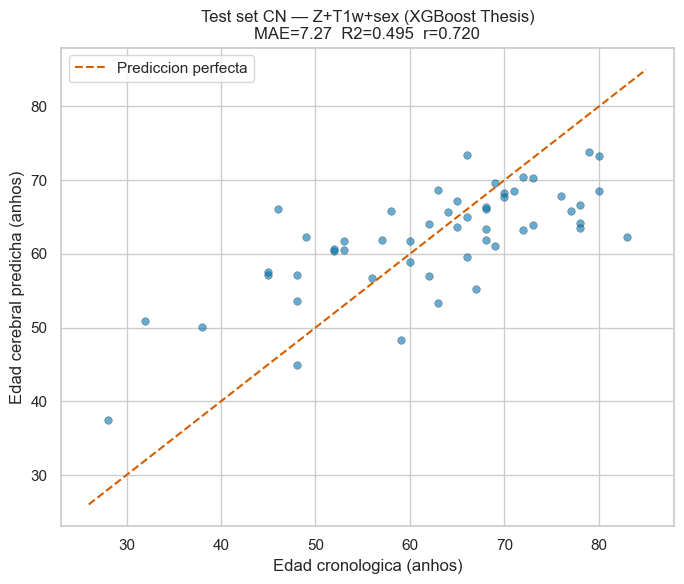

In [15]:
# Scatter: edad real vs predicha (CN test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_te, pred_te, alpha=0.6, s=30, edgecolors="k", lw=0.3)
lims = [y_te.min()-2, y_te.max()+2]
ax.plot(lims, lims, "r--", label="Prediccion perfecta")
ax.set_xlabel("Edad cronologica (anhos)")
ax.set_ylabel("Edad cerebral predicha (anhos)")
ax.set_title(f"Test set CN — Z+T1w+sex (XGBoost Thesis)\n"
             f"MAE={test_m['MAE']:.2f}  R2={test_m['R2']:.3f}  r={test_m['Pearson']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("figs/05_test_prediction.png", dpi=150)
plt.show()

## 9. BAG para todos los sujetos y estadistica

In [16]:
# Predecir en todos los sujetos con FC + T1w
# (trainval + test, todos los diagnosticos)
all_ids   = df_tv["MRI_ID"].tolist() + df_test["MRI_ID"].tolist()
df_all    = pd.concat([df_tv, df_test], ignore_index=True)
X_fc_all  = np.array([fc_vectors[s] for s in df_all["MRI_ID"]], dtype=np.float32)
X_t1w_all = df_all[t1w_cols].fillna(0).values.astype(np.float32)
X_sex_all = df_all["sex"].values.reshape(-1, 1).astype(np.float32)
y_all     = df_all["Age"].values.astype(np.float32)

mu_all, _, _ = vae.encoder.predict(X_fc_all, verbose=0)
X_all_final  = np.hstack([mu_all, X_t1w_all, X_sex_all])
pred_all     = pipe_final.predict(X_all_final)

print(f"Predicciones generadas para {len(df_all)} sujetos")

Predicciones generadas para 1245 sujetos


In [18]:
# Correccion sesgo BAG (igual que Thesis paso 9)
# LOSO por sitio: excluir CN trainval sin site (LeaveOneGroupOut no admite NaN)
mask_cn_site = df_cn_tv["site"].notna().values
n_sin_site   = int((~mask_cn_site).sum())
if n_sin_site:
    print(f"LOSO: excluyendo {n_sin_site} CN trainval sin sitio")

X_logo_cn  = X_final_cn[mask_cn_site]
y_logo_cn  = y_cn[mask_cn_site]
sites_cn   = df_cn_tv.loc[mask_cn_site, "site"].values

logo       = LeaveOneGroupOut()
pred_cv_cn = np.zeros(len(X_logo_cn))
for tr, te in logo.split(X_logo_cn, y_logo_cn, groups=sites_cn):
    p = make_xgb()
    p.fit(X_logo_cn[tr], y_logo_cn[tr])
    pred_cv_cn[te] = p.predict(X_logo_cn[te])

bag_raw_cn                     = pred_cv_cn - y_logo_cn
slope, intercept, r_b, p_b, _ = stats.linregress(y_logo_cn, bag_raw_cn)
print(f"Correlacion BAG~edad CN (LOSO, n={len(y_logo_cn)}): r={r_b:.3f}, p={p_b:.4f}")

df_all["predicted_age"] = pred_all
df_all["BAG_raw"]       = pred_all - y_all
df_all["BAG"]           = df_all["BAG_raw"] - (slope * y_all + intercept)
df_all["BAG_group"]     = (df_all["BAG"] > 0).map({True: "BAG+", False: "BAG-"})

print("\nBAG por diagnostico:")
print(df_all.groupby("diagnosis")["BAG"].agg(["mean","std","count"]).round(2))
print("\nRef Thesis (cn_only_optuna.ipynb):")
print("  CN:  BAG = -0.49 +/- 7.49")
print("  AD:  BAG = -2.21 +/- 8.83")
print("  FTD: BAG = +1.71 +/- 8.46")

LOSO: excluyendo 129 CN trainval sin sitio
Correlacion BAG~edad CN (LOSO, n=344): r=-0.848, p=0.0000

BAG por diagnostico:
           mean   std  count
diagnosis                   
AD         4.87  4.15    422
CN         2.21  8.03    526
FTD        4.73  3.98    297

Ref Thesis (cn_only_optuna.ipynb):
  CN:  BAG = -0.49 +/- 7.49
  AD:  BAG = -2.21 +/- 8.83
  FTD: BAG = +1.71 +/- 8.46


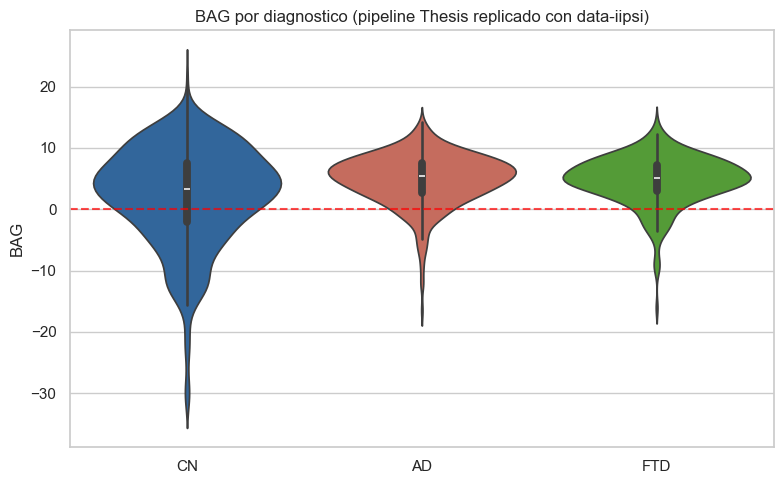

In [19]:
# Violin BAG por diagnostico
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_all[df_all.diagnosis.isin(["CN","AD","FTD"])],
               x="diagnosis", y="BAG", order=["CN","AD","FTD"],
               palette=COLORS, inner="box", ax=ax)
ax.axhline(0, color="red", ls="--", alpha=0.7)
ax.set_title("BAG por diagnostico (pipeline Thesis replicado con data-iipsi)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figs/05_BAG_by_diagnosis.png", dpi=150)
plt.show()

## 10. Guardar resultados

In [20]:
df_all.to_csv("outputs/thesis_results_table.csv", index=False)
print("Guardado:")
print("  outputs/thesis_ablation_table.csv")
print("  outputs/thesis_model_comparison.csv")
print("  outputs/thesis_results_table.csv")
print("  figs/05_ablation_comparison.png")
print("  figs/05_test_prediction.png")
print("  figs/05_BAG_by_diagnosis.png")

Guardado:
  outputs/thesis_ablation_table.csv
  outputs/thesis_model_comparison.csv
  outputs/thesis_results_table.csv
  figs/05_ablation_comparison.png
  figs/05_test_prediction.png
  figs/05_BAG_by_diagnosis.png


## 11. Topologia vs BAG_thesis vs BAG_topo

Puente entre el pipeline Thesis (VAE + T1w + XGBoost) y las metricas de grafos del Notebook 02/03.

1. Verificar cohorte estricta (`build_final_cohort_df`) y split oficial (`splits.json`) si existen artefactos en `Thesis/Outputs/`.
2. Cruzar `BAG_thesis` (seccion 9) con `BAG_topo` (Notebook 03) y `graph_metrics_table.csv`.
3. Comparar asociaciones **topo ~ BAG_thesis** vs **topo ~ BAG_topo** (BAG+ vs BAG- y regresion multiple).

In [21]:
from src.config import DEFAULT_PATHS, ExperimentConfig
from src.cohort import build_final_cohort_df
from src.splits import load_splits

cfg   = ExperimentConfig()
paths = DEFAULT_PATHS

TOPO = [
    "local_efficiency", "global_efficiency", "clustering_coeff",
    "fp_local_efficiency", "fp_betweenness", "fp_degree",
]

# --- Cohorte estricta Thesis ---
cohort_th = None
try:
    cohort_th = build_final_cohort_df(
        paths.excel_path, paths.fc_folder, paths.t1w_csv_path,
        cfg.diagnoses_to_use,
    )
    cohort_th = cohort_th.rename(columns={"record_id": "MRI_ID", "age": "Age"})
    print(f"Cohorte Thesis (build_final_cohort_df): {len(cohort_th)} sujetos")
except Exception as exc:
    print(f"No se pudo construir cohorte Thesis: {exc}")

if cohort_th is not None:
    ids_th = set(cohort_th["MRI_ID"])
    ids_nb = set(df_full["MRI_ID"])
    print(f"Interseccion Thesis / nb05: {len(ids_th & ids_nb)}")
    print(f"Solo en Thesis: {len(ids_th - ids_nb)} | Solo en nb05: {len(ids_nb - ids_th)}")

# --- Split oficial (si existe) ---
splits_path = paths.out_dir / "splits" / f"splits_seed{cfg.seed}_test{cfg.test_size}.json"
splits_official = None
if cfg.reuse_artifacts and splits_path.exists():
    splits_official = load_splits(splits_path)
    tv_off  = set(splits_official["holdout"]["trainval_ids"])
    te_off  = set(splits_official["holdout"]["test_ids"])
    tv_curr = set(split["trainval_ids"])
    te_curr = set(split["test_ids"])
    print(f"Split oficial cargado: {splits_path.name}")
    print(f"  Coincide trainval: {tv_off == tv_curr} | test: {te_off == te_curr}")
else:
    print(f"Sin {splits_path} — BAG_thesis usa el split de la seccion 2 (reentrenado localmente).")
    print("  Para replica bit-a-bit: correr Thesis/Code/notebooks/main.ipynb y copiar Thesis/Outputs/.")

Cohorte Thesis (build_final_cohort_df): 1245 sujetos
Interseccion Thesis / nb05: 1245
Solo en Thesis: 0 | Solo en nb05: 0
Sin C:\Doctorado\Neurociencia\TPFinal-NeuroComp\TPFinal-NeuroComp\Thesis\Outputs\splits\splits_seed42_test0.1.json — BAG_thesis usa el split de la seccion 2 (reentrenado localmente).
  Para replica bit-a-bit: correr Thesis/Code/notebooks/main.ipynb y copiar Thesis/Outputs/.


In [23]:
# BAG_thesis: VAE + T1w + sex (seccion 9) — solo columnas BAG (metadata viene de graph_df)
bag_th = df_all[[
    "MRI_ID", "predicted_age", "BAG", "BAG_group",
]].rename(columns={
    "predicted_age": "pred_age_thesis",
    "BAG": "BAG_thesis",
    "BAG_group": "BAG_thesis_group",
})

# BAG_topo: TOPO + XGBoost (notebook 03)
bag_topo = pd.read_csv("outputs/full_results_table.csv")[[
    "MRI_ID", "BAG", "BAG_group", "predicted_age",
]].rename(columns={
    "predicted_age": "pred_age_topo",
    "BAG": "BAG_topo",
    "BAG_group": "BAG_topo_group",
})

graph_df = pd.read_csv("outputs/graph_metrics_table.csv")

df_bridge = (
    graph_df
    .merge(bag_th, on="MRI_ID", how="inner")
    .merge(bag_topo[["MRI_ID", "BAG_topo", "BAG_topo_group", "pred_age_topo"]],
           on="MRI_ID", how="inner")
)

r_bag, p_bag = stats.pearsonr(df_bridge["BAG_thesis"], df_bridge["BAG_topo"])
print(f"Sujetos con topologia + ambos BAG: {len(df_bridge)}")
print(f"Correlacion BAG_thesis ~ BAG_topo: r={r_bag:.3f}, p={p_bag:.4g}")
print("\nBAG_thesis por diagnostico:")
print(df_bridge.groupby("diagnosis")["BAG_thesis"].agg(["mean", "std", "count"]).round(2))
print("\nBAG_topo por diagnostico:")
print(df_bridge.groupby("diagnosis")["BAG_topo"].agg(["mean", "std", "count"]).round(2))

Sujetos con topologia + ambos BAG: 1245
Correlacion BAG_thesis ~ BAG_topo: r=0.541, p=9.127e-96

BAG_thesis por diagnostico:
           mean   std  count
diagnosis                   
AD         4.87  4.15    422
CN         2.21  8.03    526
FTD        4.73  3.98    297

BAG_topo por diagnostico:
           mean   std  count
diagnosis                   
AD         0.75  6.70    422
CN         1.12  9.42    526
FTD        1.04  5.90    297


In [24]:
def _pg_val(r, *candidates):
    for c in candidates:
        if c in r.columns:
            return float(r[c].iloc[0])
    raise KeyError(f"Ninguna columna en {list(r.columns)}: {candidates}")


def compare_groups(df, metrics, col_group, g1="BAG+", g2="BAG-"):
    rows = []
    for m in metrics:
        pos = df.loc[df[col_group] == g1, m].dropna()
        neg = df.loc[df[col_group] == g2, m].dropna()
        if len(pos) < 3 or len(neg) < 3:
            continue
        if pos.var() < 1e-12 and neg.var() < 1e-12:
            continue
        if pg.normality(pos).iloc[0]["normal"] and pg.normality(neg).iloc[0]["normal"]:
            r = pg.ttest(pos, neg)
            stat, test = _pg_val(r, "T"), "t-test"
        else:
            r = pg.mwu(pos, neg)
            stat, test = _pg_val(r, "U_val", "U-val"), "MWU"
        rows.append({
            "metric": m,
            "test": test,
            "stat": round(stat, 3),
            "p_val": _pg_val(r, "p_val", "p-val"),
            "mean_pos": round(pos.mean(), 4),
            "mean_neg": round(neg.mean(), 4),
        })
    out = pd.DataFrame(rows)
    if len(out):
        out["p_fdr"] = multipletests(out["p_val"], method="fdr_bh")[1]
    return out


cmp_th   = compare_groups(df_bridge, TOPO, "BAG_thesis_group")
cmp_topo = compare_groups(df_bridge, TOPO, "BAG_topo_group")

cmp_th["BAG_source"]   = "thesis"
cmp_topo["BAG_source"] = "topo"
bag_cmp_both = pd.concat([cmp_th, cmp_topo], ignore_index=True)

print("=== BAG+ vs BAG- (BAG_thesis) ===")
print(cmp_th.round(4).to_string(index=False))
print("\n=== BAG+ vs BAG- (BAG_topo) ===")
print(cmp_topo.round(4).to_string(index=False))

=== BAG+ vs BAG- (BAG_thesis) ===
             metric test     stat  p_val  mean_pos  mean_neg  p_fdr BAG_source
   local_efficiency  MWU 144977.0 0.0000    0.8603    0.8436 0.0000     thesis
  global_efficiency  MWU 144470.5 0.0000    0.7603    0.7334 0.0000     thesis
   clustering_coeff  MWU 144232.0 0.0000    0.7263    0.6944 0.0000     thesis
fp_local_efficiency  MWU 140645.0 0.0002    0.8588    0.8438 0.0003     thesis
     fp_betweenness  MWU 104044.0 0.0004    0.0051    0.0056 0.0004     thesis
          fp_degree  MWU 140140.0 0.0003    0.5882    0.5388 0.0003     thesis

=== BAG+ vs BAG- (BAG_topo) ===
             metric test     stat  p_val  mean_pos  mean_neg  p_fdr BAG_source
   local_efficiency  MWU 248576.0    0.0    0.8688    0.8397    0.0       topo
  global_efficiency  MWU 243658.0    0.0    0.7727    0.7290    0.0       topo
   clustering_coeff  MWU 247832.0    0.0    0.7432    0.6859    0.0       topo
fp_local_efficiency  MWU 242773.0    0.0    0.8672    0.8392    

In [25]:
def run_topo_regressions(df, bag_col, source_label):
    rows = []
    df_reg = df.dropna(subset=TOPO + [bag_col, "Age", "years_education", "site"])
    for m in TOPO:
        sub = df_reg.dropna(subset=[m])
        if len(sub) < 30:
            continue
        mod = smf.ols(
            f"{m} ~ {bag_col} + Age + years_education + C(sex) + C(site) + C(diagnosis)",
            data=sub,
        ).fit()
        ci = mod.conf_int().loc[bag_col]
        rows.append({
            "metric": m,
            "BAG_source": source_label,
            "beta_BAG": mod.params[bag_col],
            "p_val": mod.pvalues[bag_col],
            "CI_low": ci[0],
            "CI_high": ci[1],
            "R2_adj": mod.rsquared_adj,
            "n": int(mod.nobs),
        })
    out = pd.DataFrame(rows)
    if len(out):
        out["p_fdr"] = multipletests(out["p_val"], method="fdr_bh")[1]
    return out


reg_th   = run_topo_regressions(df_bridge, "BAG_thesis", "thesis")
reg_topo = run_topo_regressions(df_bridge, "BAG_topo", "topo")
reg_compare = pd.concat([reg_th, reg_topo], ignore_index=True)

# Tabla lado a lado
side = (
    reg_th.set_index("metric")[["beta_BAG", "p_val", "p_fdr"]]
    .rename(columns={"beta_BAG": "beta_thesis", "p_val": "p_thesis", "p_fdr": "fdr_thesis"})
    .join(
        reg_topo.set_index("metric")[["beta_BAG", "p_val", "p_fdr"]]
        .rename(columns={"beta_BAG": "beta_topo", "p_val": "p_topo", "p_fdr": "fdr_topo"}),
        how="outer",
    )
    .reset_index()
)
side["sign_agree"] = np.sign(side["beta_thesis"]) == np.sign(side["beta_topo"])
side["sig_both"]   = (side["fdr_thesis"] < 0.05) & (side["fdr_topo"] < 0.05)

print("=== Regresion: topologia ~ BAG + covariables ===")
print(side.round(4).to_string(index=False))
print(f"\nCoincidencia de signo beta: {side['sign_agree'].sum()}/{len(side)}")
print(f"Significativas FDR en ambos: {side['sig_both'].sum()}/{len(side)}")

=== Regresion: topologia ~ BAG + covariables ===
             metric  beta_thesis  p_thesis  fdr_thesis  beta_topo  p_topo  fdr_topo  sign_agree  sig_both
   clustering_coeff       0.0014    0.0304      0.0456     0.0035     0.0       0.0        True      True
     fp_betweenness      -0.0000    0.0287      0.0456    -0.0000     0.0       0.0        True      True
          fp_degree       0.0032    0.0065      0.0195     0.0058     0.0       0.0        True      True
fp_local_efficiency       0.0007    0.0560      0.0560     0.0017     0.0       0.0        True     False
  global_efficiency       0.0015    0.0041      0.0195     0.0026     0.0       0.0        True      True
   local_efficiency       0.0006    0.0530      0.0560     0.0018     0.0       0.0        True     False

Coincidencia de signo beta: 6/6
Significativas FDR en ambos: 4/6


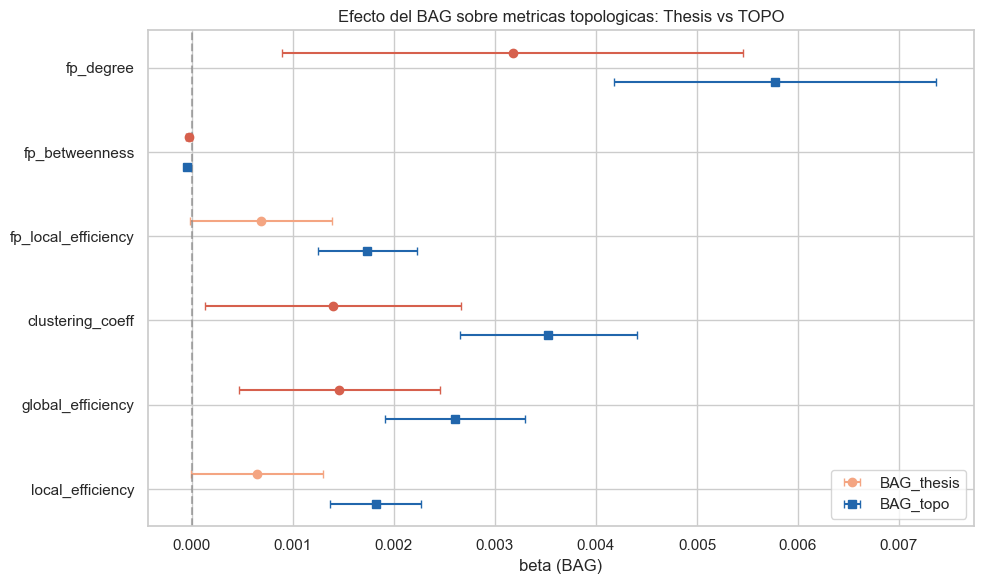

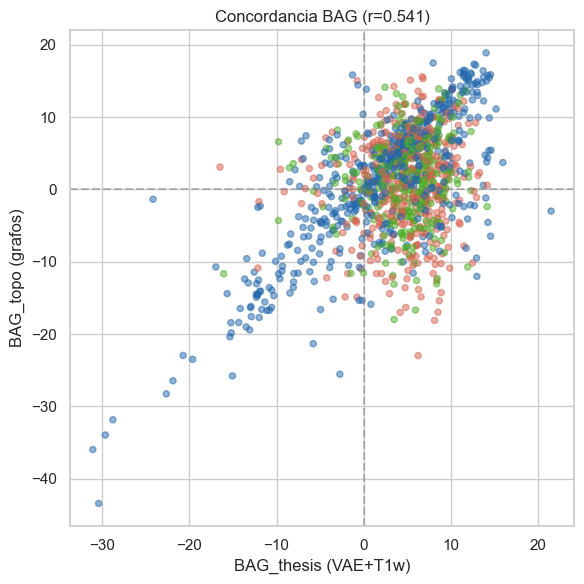

In [26]:
# Forest plot comparativo
fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(reg_th))
h = 0.35

for i, row in reg_th.iterrows():
    m = row["metric"]
    y = ypos[i]
    sig_th = row["p_fdr"] < 0.05
    sig_to = reg_topo.loc[reg_topo.metric == m, "p_fdr"].iloc[0] < 0.05
    ax.errorbar(
        row["beta_BAG"], y + h / 2,
        xerr=[[row["beta_BAG"] - row["CI_low"]], [row["CI_high"] - row["beta_BAG"]]],
        fmt="o", color="#d6604d" if sig_th else "#f4a582",
        capsize=3, label="BAG_thesis" if i == 0 else "",
    )
    rt = reg_topo.loc[reg_topo.metric == m].iloc[0]
    ax.errorbar(
        rt["beta_BAG"], y - h / 2,
        xerr=[[rt["beta_BAG"] - rt["CI_low"]], [rt["CI_high"] - rt["beta_BAG"]]],
        fmt="s", color="#2166ac" if sig_to else "#92c5de",
        capsize=3, label="BAG_topo" if i == 0 else "",
    )

ax.axvline(0, color="gray", ls="--", alpha=0.6)
ax.set_yticks(ypos)
ax.set_yticklabels(reg_th["metric"])
ax.set_xlabel("beta (BAG)")
ax.set_title("Efecto del BAG sobre metricas topologicas: Thesis vs TOPO")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figs/05_topo_BAG_thesis_vs_topo.png", dpi=150)
plt.show()

# Scatter BAG_thesis vs BAG_topo
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_bridge["BAG_thesis"], df_bridge["BAG_topo"],
           c=df_bridge["diagnosis"].map(COLORS), alpha=0.5, s=20)
ax.axhline(0, color="gray", ls="--", alpha=0.5)
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("BAG_thesis (VAE+T1w)")
ax.set_ylabel("BAG_topo (grafos)")
ax.set_title(f"Concordancia BAG (r={r_bag:.3f})")
plt.tight_layout()
plt.savefig("figs/05_BAG_thesis_vs_topo_scatter.png", dpi=150)
plt.show()

In [27]:
df_bridge.to_csv("outputs/thesis_topo_bridge_table.csv", index=False)
bag_cmp_both.to_csv("outputs/thesis_topo_BAG_groups.csv", index=False)
reg_compare.to_csv("outputs/thesis_topo_regression_compare.csv", index=False)
side.to_csv("outputs/thesis_topo_regression_side_by_side.csv", index=False)

print("Guardado:")
print("  outputs/thesis_topo_bridge_table.csv")
print("  outputs/thesis_topo_BAG_groups.csv")
print("  outputs/thesis_topo_regression_compare.csv")
print("  outputs/thesis_topo_regression_side_by_side.csv")
print("  figs/05_topo_BAG_thesis_vs_topo.png")
print("  figs/05_BAG_thesis_vs_topo_scatter.png")

Guardado:
  outputs/thesis_topo_bridge_table.csv
  outputs/thesis_topo_BAG_groups.csv
  outputs/thesis_topo_regression_compare.csv
  outputs/thesis_topo_regression_side_by_side.csv
  figs/05_topo_BAG_thesis_vs_topo.png
  figs/05_BAG_thesis_vs_topo_scatter.png
